# 0. load libraries

In [3]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "1"

In [4]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.sparse as sp
import h5py
import anndata as ad
from gtfparse import read_gtf

In [5]:
import importlib
print("Package versions:")
for package_name in ["numpy", "pandas", "scanpy", "matplotlib", "seaborn", "scipy", "anndata", "harmonypy"]:
    print(f"- {package_name}: {importlib.metadata.version(package_name)}")

Package versions:
- numpy: 2.4.6
- pandas: 2.3.3
- scanpy: 1.12.1
- matplotlib: 3.10.9
- seaborn: 0.13.2
- scipy: 1.17.1
- anndata: 0.12.16
- harmonypy: 2.0.0


# 1. Load data

In [6]:
# load data
adata_protein = ad.read_h5ad("/home/ubuntu/data/frangieh/protein.h5ad")
adata_rna = ad.read_h5ad("/home/ubuntu/data/frangieh/rna.h5ad")

# 2. observe data 
- **AnnData format:** combines data matrix (rows = cells, cols = genes) with metadata from the cells 


Spalten: Gene (var)
             ┌─────────────────────────┐
             │                         │
 rows:       │    main matrix          │  <-- adata.X (Expression matrix)
 cells       |       (adata.X)         │
  (obs)      │                         │
             └─────────────────────────┘
             ┌─────────────────────────┐
             │ Metadata of cells       │  <-- adata.obs (cell-annotation, z.B. condition, Gene-Knockout)
             └─────────────────────────┘
             ┌─────────────────────────┐
             │ Metadata of Genes       │  <-- adata.var (Gene-annotation, z.B. Gen-names)
             └─────────────────────────┘


In [7]:
print(adata_protein)
print(adata_rna)

AnnData object with n_obs × n_vars = 218331 × 24
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'Target', 'Clone', 'TotalSeq A#', 'Barcode', 'Isotype_control', 'ncounts', 'ncells'
AnnData object with n_obs × n_vars = 218331 × 23712
    obs: 'library_preparation_protocol', 'perturbation_2', 'MOI', 'sgRNA', 'UMI_count', 'guide_id', 'perturbation', 'tissue_type', 'cancer', 'disease', 'perturbation_type', 'celltype', 'organism', 'perturbation_type_2', 'nperts', 'ngenes', 'ncounts', 'percent_mito', 'percent_ribo'
    var: 'ensembl_id', 'ncounts', 'ncells'


In [11]:

print(adata_rna.obs['perturbation_2'].value_counts()) # cells per conditions (IFn-gamma, control, co-culture)
print(adata_rna.obs['perturbation'].value_counts().head(10)) # cells per KO, top 10 KOs

perturbation_2
IFNγ          87590
Co-culture    73114
Control       57627
Name: count, dtype: int64
perturbation
control    57605
ACTA2       1458
B2M         1379
A2M         1331
AEBP1       1302
CD59        1238
CD274       1222
CTSD        1217
IFNGR2      1203
CSPG4       1195
Name: count, dtype: int64


In [8]:
print(adata_protein.obs.head())

          library_preparation_protocol perturbation_2  MOI    sgRNA  \
cell_name                                                             
CELL_1            10X 3' v3 sequencing        Control    1  HLA-B_2   
CELL_2            10X 3' v3 sequencing        Control    2      nan   
CELL_3            10X 3' v3 sequencing        Control    1  HLA-B_2   
CELL_4            10X 3' v3 sequencing        Control    2      nan   
CELL_5            10X 3' v3 sequencing        Control    0      nan   

           UMI_count           guide_id perturbation           tissue_type  \
cell_name                                                                    
CELL_1       10832.0            HLA-B_2        HLA-B  cell_line_co-culture   
CELL_2       10731.0  NGFR_3;SERPINF1_3         NGFR  cell_line_co-culture   
CELL_3       28821.0            HLA-B_2        HLA-B  cell_line_co-culture   
CELL_4       15322.0   NMRK1_3;S100A6_3        NMRK1  cell_line_co-culture   
CELL_5       10314.0              

### 3. Visualization of data exploration and data distribution

/tmp/ipykernel_35923/2236916539.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


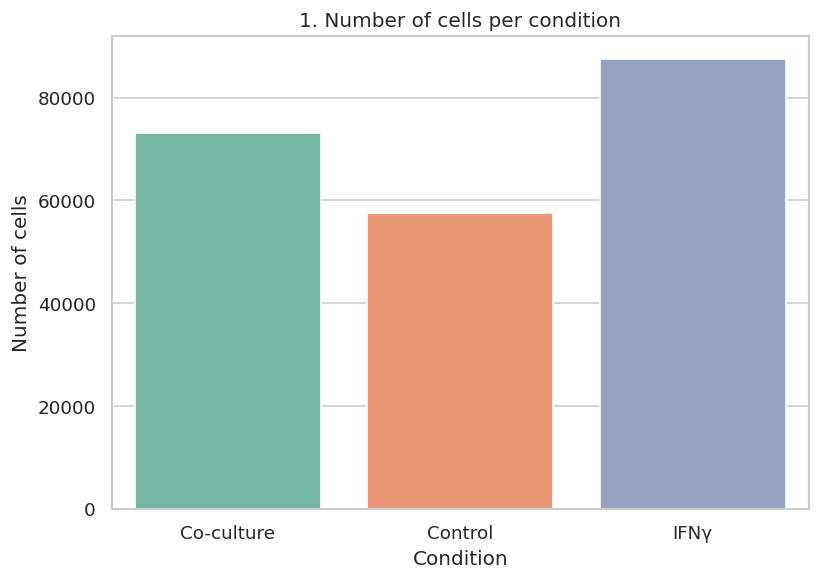

In [9]:
# cells per condition
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.figure(figsize=(7, 5))


sns.countplot(
    data=adata_rna.obs, 
    x='perturbation_2', 
    palette='Set2'
)


plt.title("1. Number of cells per condition")
plt.xlabel("Condition")
plt.ylabel("Number of cells")


plt.tight_layout()
plt.show()

/tmp/ipykernel_35923/2902791169.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Text(0, 0.5, 'Number of cells')

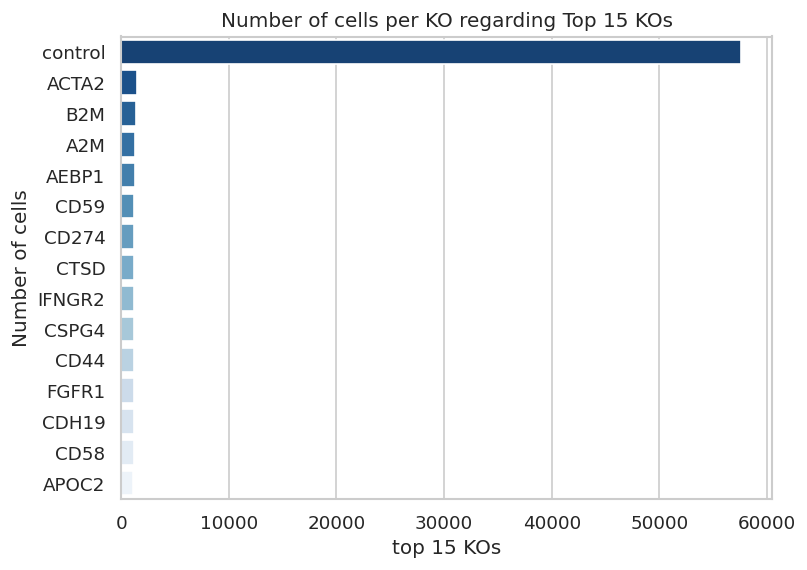

In [11]:
# top 15 pertubations 
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.figure(figsize=(7, 5))

top_perts = adata_rna.obs['perturbation'].value_counts().head(15).index
sns.countplot(
    data=adata_rna.obs[adata_rna.obs['perturbation'].isin(top_perts)], 
    y='perturbation', 
    order=top_perts,
    palette='Blues_r'
)

plt.title("Number of cells per KO regarding Top 15 KOs")
plt.xlabel("top 15 KOs")
plt.ylabel("Number of cells")